In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from numba import jit
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid
import math

Max error: 1.232e-14


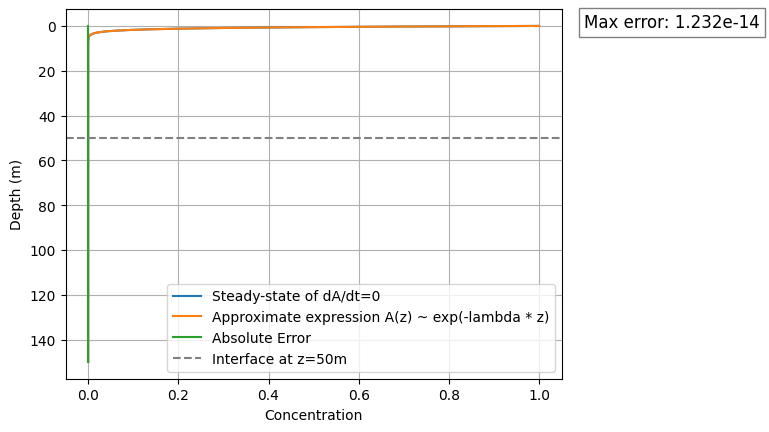

In [7]:
alpha = 1.74
Da=1
L=150

lambda_ = np.sqrt(alpha/Da)

Nx = 1000
z=np.linspace(0,L,Nx)

Old_A = np.zeros_like(z)
New_A = np.zeros_like(z)

Old_A = np.sinh(lambda_ * (150 - z)) / np.sinh(lambda_ * 150)  

New_A = np.exp(-lambda_ * z)  

error = np.abs(Old_A - New_A)
print(f"Max error: {np.max(error):.3e}")

plt.plot( Old_A,z, label="Steady-state of dA/dt=0")
plt.plot( New_A,z, label="Approximate expression A(z) ~ exp(-lambda * z)")
plt.plot( error,z, label="Absolute Error")
plt.xlabel("Concentration")
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()
plt.axhline(50, color='gray', linestyle='--', label="Interface at z=50m")
#plt.title("Comparison of steady-state solutions to A(z)")
plt.text(1.1, 0.5, f"Max error: {np.max(error):.3e}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.legend()
plt.grid()
plt.show()